In [ ]:
# Replicating this paper's findings. 

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [10]:

# =========================================================
# Table 1: parameters from the paper (replicating the equations in eq. 6)
# =========================================================
params = {
    # Tumor
    "lambda_C": 1.5,
    "C_M": 0.8,
    "eta_8": 328.55,
    "eta_N": 300.0,
    "d_C": 0.17,

    # DCs
    "lambda_DC": 4.0,
    "D0": 2e-5,          # baseline level of inactive DCs
    "K_C": 0.4,
    "d_D": 0.1,

    # NK cells
    "sigma_N": 5e-5,
    "d_N": 0.1,
    "gamma_N": 150.0,
    "a_C": 0.5,
    "beta_1": 0.4,
    "beta_2": 2e-4,

    # Tregs
    "d_Treg": 0.2,
    "lambda_Treg": 0.5,
    "T10": 4e-4,         # baseline level of regulatory T cell precursors

    # CD8 T cells
    "d_T8": 0.18,
    "lambda_T8": 5.4,
    "T80": 2e-4,         # baseline level of CD8 T cell precursors
    "K_Treg": 2.5e-4,
    "K_D": 4e-4,
}

# =========================================================
# Table 2: initial conditions from the paper
# State order: [C, D, N, Treg, T8]
# =========================================================
y0 = np.array([
    0.4,      # C(0)
    4e-4,     # D(0)
    3e-4,     # N(0)
    5e-4,     # Treg(0)
    1.5e-3    # T8(0)
], dtype=float)

# =========================================================
# Eq. (6) from the paper
# =========================================================
def tumor_immune_model(t, y, p):
    C, D, N, Treg, T8 = y
    # Tumor cell dynamics
    dCdt = (
        p["lambda_C"] * C * (1 - C / p["C_M"])
        - p["eta_8"] * T8 * C
        - p["eta_N"] * N * C
        - p["d_C"] * C
    )
    # Dendritic cell dynamics
    dDdt = (
        p["lambda_DC"] * p["D0"] * C / (p["K_C"] + C)
        - p["d_D"] * D
    )
    # NK cell dynamics
    dNdt = (
        p["sigma_N"]
        - p["d_N"] * N
        - p["gamma_N"] * Treg * N
        + p["a_C"] * N * C / (1 + C / p["beta_1"] + N / p["beta_2"])
    )
    # Regulatory T cell dynamics
    dTregdt = (
        - p["d_Treg"] * Treg
        + p["lambda_Treg"] * p["T10"] * C / (p["K_C"] + C)
    )
    # CD8+ T cell dynamics
    dT8dt = (
        - p["d_T8"] * T8
        + p["lambda_T8"] * p["T80"] * D / (p["K_D"] + D) * 1 / (1 + Treg / p["K_Treg"])
    )

    return [dCdt, dDdt, dNdt, dTregdt, dT8dt]



In [8]:
# =========================================================
# Simulate
# =========================================================
t_span = (0, 200)
t_eval = np.linspace(0, 200, 1001) # 200 days, 1001 points 

sol = solve_ivp(
    fun=lambda t, y: tumor_immune_model(t, y, params),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)


In [ ]:
# The example output

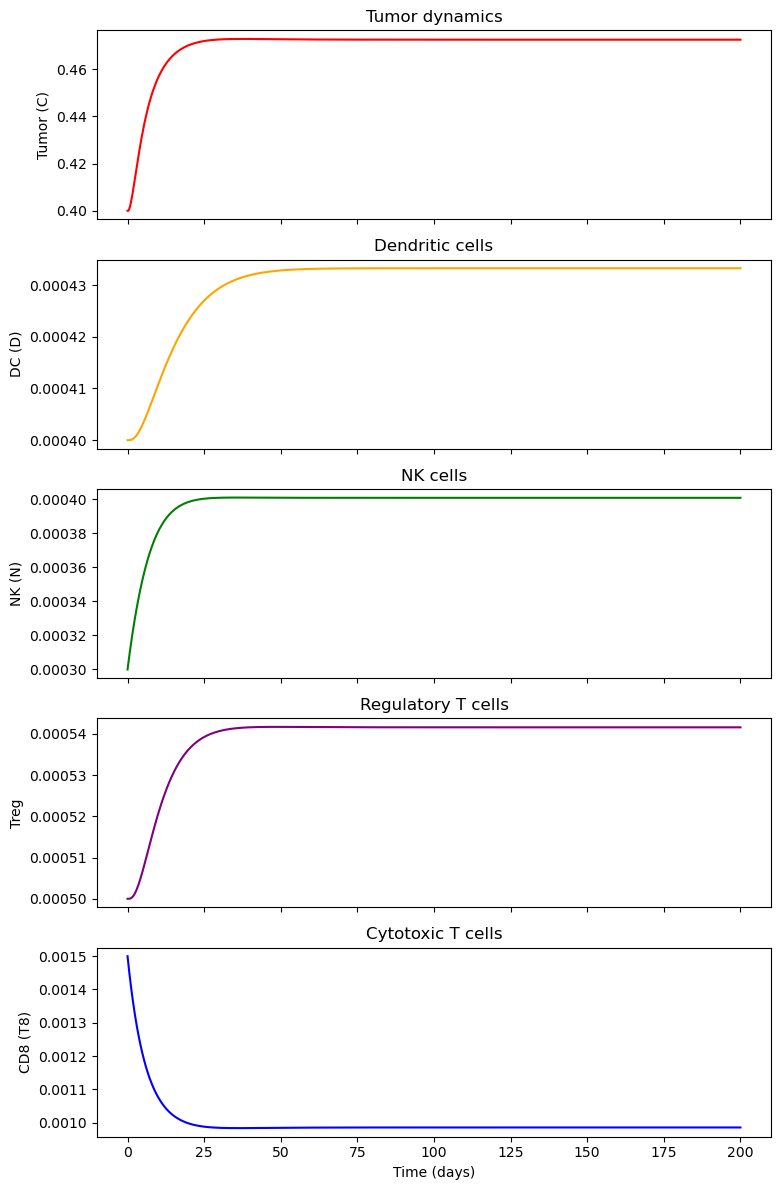

In [11]:
fig, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True)

# Tumor
axes[0].plot(sol.t, sol.y[0], color="red")
axes[0].set_ylabel("Tumor (C)")
axes[0].set_title("Tumor dynamics")

# DC
axes[1].plot(sol.t, sol.y[1], color="orange")
axes[1].set_ylabel("DC (D)")
axes[1].set_title("Dendritic cells")

# NK
axes[2].plot(sol.t, sol.y[2], color="green")
axes[2].set_ylabel("NK (N)")
axes[2].set_title("NK cells")

# Treg
axes[3].plot(sol.t, sol.y[3], color="purple")
axes[3].set_ylabel("Treg")
axes[3].set_title("Regulatory T cells")

# CD8
axes[4].plot(sol.t, sol.y[4], color="blue")
axes[4].set_ylabel("CD8 (T8)")
axes[4].set_title("Cytotoxic T cells")
axes[4].set_xlabel("Time (days)")

plt.tight_layout()
plt.show()

# Analyze the impact of baseline immunity on dynamic evolution
# Sweep between 1X10^-4 to-6 X 10^-4

In [46]:
# =========================================================
# PART 1: Fix T10, sweep T80
# =========================================================

params["T10"] = 4e-4
T80_space = np.linspace(1e-4, 6e-4, 50)

# store results
C_vals = []
D_vals = []
N_vals = []
Treg_vals = []
T8_vals = []

for T80_val in T80_space:

    params["T80"] = T80_val

    sol = solve_ivp(
        fun=lambda t, y: tumor_immune_model(t, y, params),
        t_span=(0, 200),
        y0=y0,
        t_eval=[200],
        method="LSODA"
    )

    C_vals.append(sol.y[0][-1])
    D_vals.append(sol.y[1][-1])
    N_vals.append(sol.y[2][-1])
    Treg_vals.append(sol.y[3][-1])
    T8_vals.append(sol.y[4][-1])

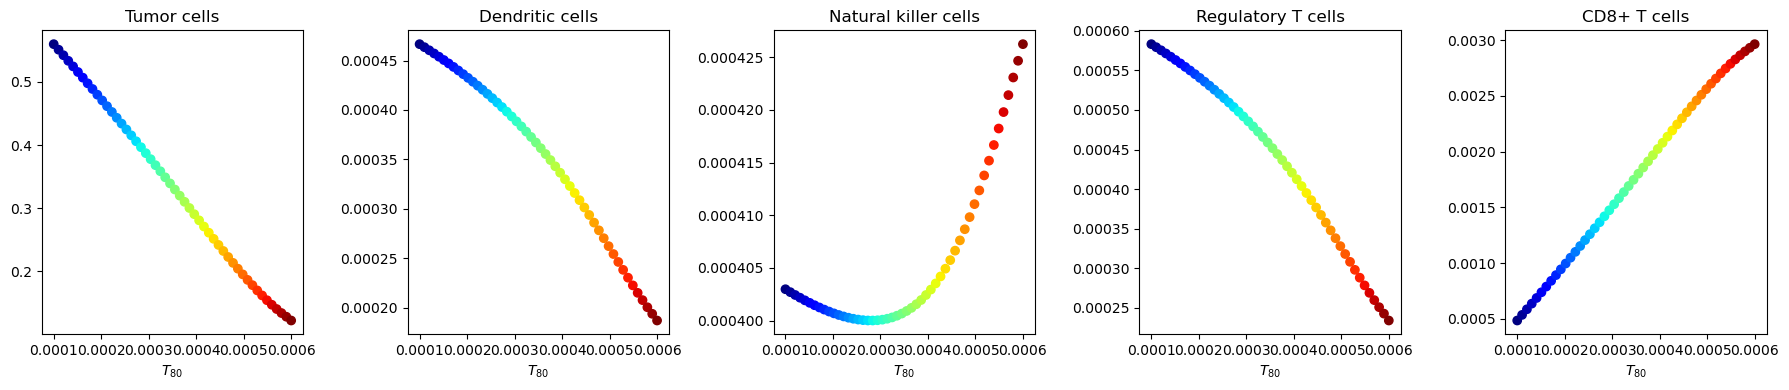

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18,4))

# colormap
cmap = plt.cm.jet
colors = cmap((T80_space - T80_space.min()) / (T80_space.max() - T80_space.min()))

# Tumor
sc = axes[0].scatter(T80_space, C_vals, c=colors)
axes[0].set_title("Tumor cells")
axes[0].set_xlabel(r"$T_{80}$")

# DC
axes[1].scatter(T80_space, D_vals, c=colors)
axes[1].set_title("Dendritic cells")
axes[1].set_xlabel(r"$T_{80}$")

# NK
axes[2].scatter(T80_space, N_vals, c=colors)
axes[2].set_title("Natural killer cells")
axes[2].set_xlabel(r"$T_{80}$")

# Treg
axes[3].scatter(T80_space, Treg_vals, c=colors)
axes[3].set_title("Regulatory T cells")
axes[3].set_xlabel(r"$T_{80}$")

# CD8
axes[4].scatter(T80_space, T8_vals, c=colors)
axes[4].set_title("CD8+ T cells")
axes[4].set_xlabel(r"$T_{80}$")

plt.tight_layout()
plt.show()

In [22]:
# =========================================================
# PART 2: Fix T80, sweep T10
# =========================================================

params["T80"] = 2e-4
T10_space = np.linspace(1e-4, 6e-4, 50)

C_vals = []
D_vals = []
N_vals = []
Treg_vals = []
T8_vals = []

for T10_val in T10_space:

    params["T10"] = T10_val

    sol = solve_ivp(
        fun=lambda t, y: tumor_immune_model(t, y, params),
        t_span=(0, 200),
        y0=y0,
        t_eval=[200],
        method="LSODA"
    )

    C_vals.append(sol.y[0][-1])
    D_vals.append(sol.y[1][-1])
    N_vals.append(sol.y[2][-1])
    Treg_vals.append(sol.y[3][-1])
    T8_vals.append(sol.y[4][-1])

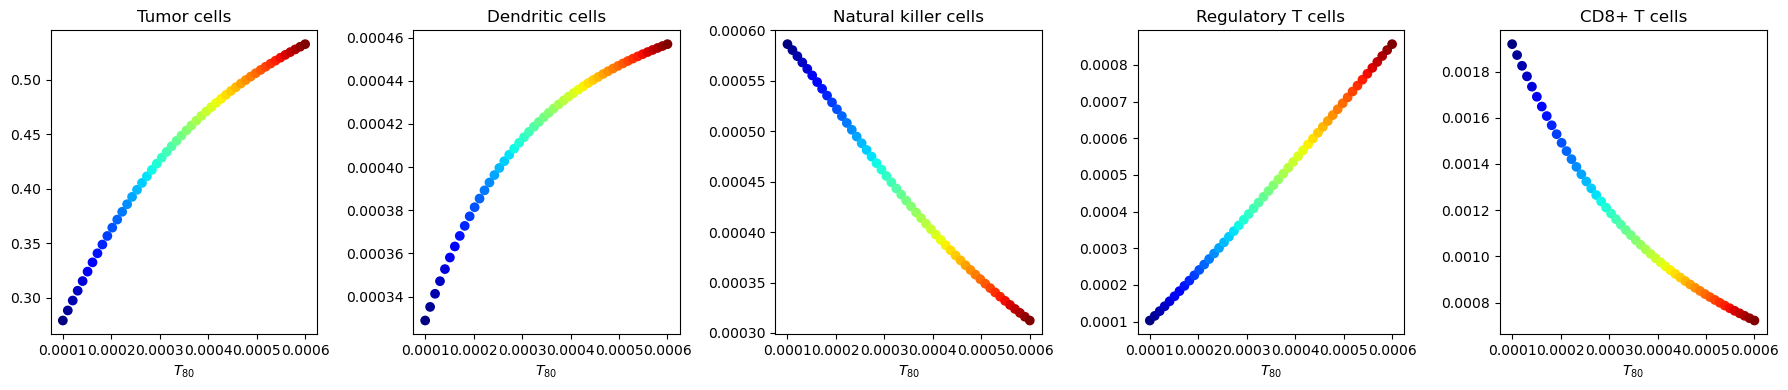

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(18,4))

# colormap
cmap = plt.cm.jet
colors = cmap((T10_space - T10_space.min()) / (T10_space.max() - T10_space.min()))

# Tumor
sc = axes[0].scatter(T10_space, C_vals, c=colors)
axes[0].set_title("Tumor cells")
axes[0].set_xlabel(r"$T_{80}$")

# DC
axes[1].scatter(T10_space, D_vals, c=colors)
axes[1].set_title("Dendritic cells")
axes[1].set_xlabel(r"$T_{80}$")

# NK
axes[2].scatter(T10_space, N_vals, c=colors)
axes[2].set_title("Natural killer cells")
axes[2].set_xlabel(r"$T_{80}$")

# Treg
axes[3].scatter(T10_space, Treg_vals, c=colors)
axes[3].set_title("Regulatory T cells")
axes[3].set_xlabel(r"$T_{80}$")

# CD8
axes[4].scatter(T10_space, T8_vals, c=colors)
axes[4].set_title("CD8+ T cells")
axes[4].set_xlabel(r"$T_{80}$")

plt.tight_layout()
plt.show()

### Two parameter space

In [25]:
# Run the baseline model:
# baseline simulation
sol_base = solve_ivp(
    fun=lambda t, y: tumor_immune_model(t, y, params),
    t_span=(0,200),
    y0=y0,
    t_eval=[200],
    method="LSODA"
)

baseline = sol_base.y[:, -1]   # [C, D, N, Treg, T8]

In [26]:
# Define parameter space
T10_space = np.linspace(1e-4, 6e-4, 50)
T80_space = np.linspace(1e-4, 6e-4, 50)

In [27]:
# Store composite index
EC = np.zeros((len(T10_space), len(T80_space)))
ED = np.zeros_like(EC)
EN = np.zeros_like(EC)
ETreg = np.zeros_like(EC)
ET8 = np.zeros_like(EC)

In [28]:
# Run the sweep
for i, T10_val in enumerate(T10_space):
    for j, T80_val in enumerate(T80_space):

        params["T10"] = T10_val
        params["T80"] = T80_val

        sol = solve_ivp(
            fun=lambda t, y: tumor_immune_model(t, y, params),
            t_span=(0,200),
            y0=y0,
            t_eval=[200],
            method="LSODA"
        )

        result = sol.y[:, -1]

        # composite index
        EC[i,j]    = (result[0] - baseline[0]) / baseline[0]
        ED[i,j]    = (result[1] - baseline[1]) / baseline[1]
        EN[i,j]    = (result[2] - baseline[2]) / baseline[2]
        ETreg[i,j] = (result[3] - baseline[3]) / baseline[3]
        ET8[i,j]   = (result[4] - baseline[4]) / baseline[4]

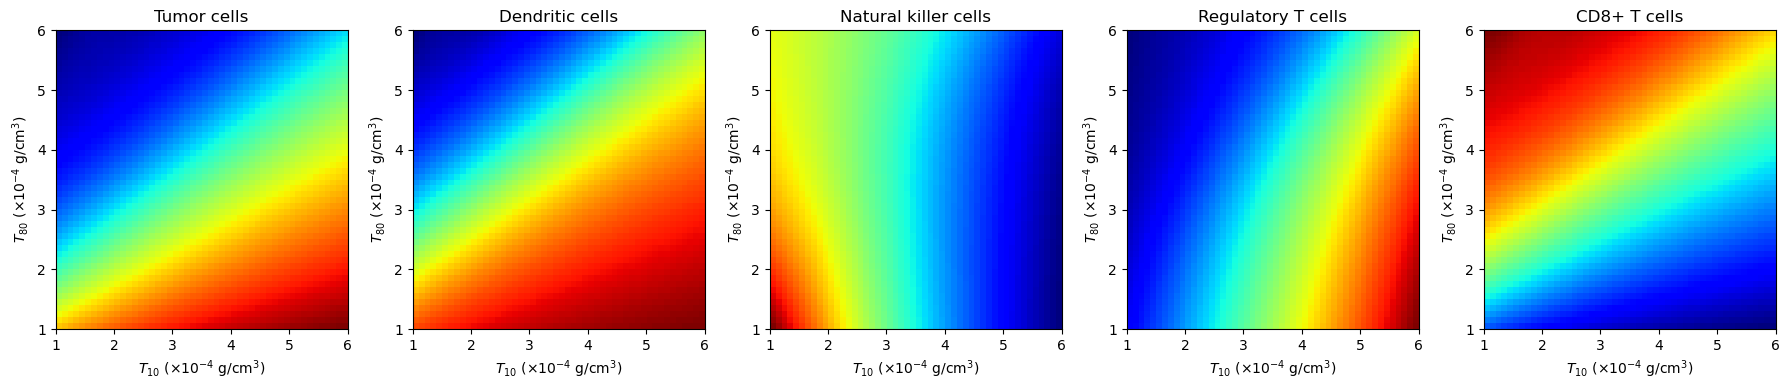

In [30]:
T10_scaled = T10_space / 1e-4
T80_scaled = T80_space / 1e-4

fig, axes = plt.subplots(1,5, figsize=(18,4))

extent = [
    T10_scaled.min(), T10_scaled.max(),
    T80_scaled.min(), T80_scaled.max()
]

im0 = axes[0].imshow(EC.T, origin='lower', extent=extent, aspect='auto', cmap='jet')
axes[0].set_title("Tumor cells")

im1 = axes[1].imshow(ED.T, origin='lower', extent=extent, aspect='auto', cmap='jet')
axes[1].set_title("Dendritic cells")

im2 = axes[2].imshow(EN.T, origin='lower', extent=extent, aspect='auto', cmap='jet')
axes[2].set_title("Natural killer cells")

im3 = axes[3].imshow(ETreg.T, origin='lower', extent=extent, aspect='auto', cmap='jet')
axes[3].set_title("Regulatory T cells")

im4 = axes[4].imshow(ET8.T, origin='lower', extent=extent, aspect='auto', cmap='jet')
axes[4].set_title("CD8+ T cells")

for ax in axes:
    ax.set_xlabel(r"$T_{10}$ ($\times10^{-4}$ g/cm$^3$)")
    ax.set_ylabel(r"$T_{80}$ ($\times10^{-4}$ g/cm$^3$)")
    
    ax.set_xticks([1,2,3,4,5,6])
    ax.set_yticks([1,2,3,4,5,6])

plt.tight_layout()
plt.show()

# Numerical analysis and stability of equilibria

### The number of steady states at different parameter values

C_M, sigma_N, d_N, d_C, eta_N, T10

First, investigate the variations in the parameters sigma_N and C_M
Employ color codes: magenta for one, cyan for 2 and yellow for 3 stability equilibria
The four steps: 
1. Sweep the two parameters
2. For each pair, numerically search for steady states.
3. Count distinct positive solutions
4. Color-code the count.

Bifurcation diagram vs sigma_N

Bifurcation diagram vs C_M

In [ ]:
# Part A - number of positive steady states
# Solve ODEs

In [50]:
# DC steady state
def DC_stable(C, p):
    return (p["lambda_DC"] * p["D0"] * C) / (p["d_D"] * (p["K_C"] + C))

def Treg_stable(C, p):
    return (p["lambda_Treg"] * p["T10"] * C) / (p["d_Treg"] * (p["K_C"] + C))


def CD8_stable(C, p):

    DC = DC_stable(C, p)
    Treg = Treg_stable(C, p)

    return (
        (p["lambda_T8"] * p["T80"] * DC) /
        (p["d_T8"] * (p["K_D"] + DC)) *
        (1 / (1 + Treg / p["K_Treg"]))
    )

def NK_stable(C, p):

    CD8 = CD8_stable(C, p)

    return (
        p["lambda_C"] * (1 - C / p["C_M"])
        - p["eta_8"] * CD8
        - p["d_C"]
    ) / p["eta_N"]

In [51]:
# reduced tumor equation
def tumor_reduced_equation(C, p):

    NK = NK_stable(C, p)
    Treg = Treg_stable(C, p)

    term1 = p["sigma_N"]

    term2 = p["a_C"] * NK * C / (
        1 + C / p["beta_1"] + NK / p["beta_2"]
    )

    term3 = p["gamma_N"] * Treg * NK
    term4 = p["d_N"] * NK

    return term1 + term2 - term3 - term4

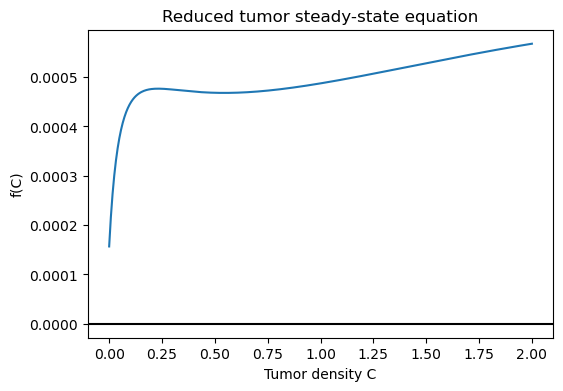

In [53]:
C_vals = np.linspace(0, 2, 500)

f_vals = [tumor_reduced_equation(C, params) for C in C_vals]

plt.figure(figsize=(6,4))
plt.plot(C_vals, f_vals)
plt.axhline(0,color="black")
plt.xlabel("Tumor density C")
plt.ylabel("f(C)")
plt.title("Reduced tumor steady-state equation")
plt.show()

In [54]:
# Find roots
from scipy.optimize import root_scalar

roots = []

for guess in np.linspace(0.01,2,20):

    try:
        sol = root_scalar(
            tumor_reduced_eq,
            args=(params,),
            bracket=[guess, guess+0.1]
        )

        if sol.converged:
            roots.append(sol.root)

    except:
        pass

print(roots)

[]


/tmp/ipykernel_2248/206516884.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  + p["lambda_T8"] * p["T80"] * D / (p["K_D"] + D) * 1 / (1 + Treg / p["K_Treg"])
/tmp/ipykernel_2248/206516884.py:58: RuntimeWarning: invalid value encountered in scalar subtract
  p["lambda_C"] * C * (1 - C / p["C_M"])
/tmp/ipykernel_2248/206516884.py:65: RuntimeWarning: invalid value encountered in scalar divide
  p["lambda_DC"] * p["D0"] * C / (p["K_C"] + C)
/tmp/ipykernel_2248/206516884.py:73: RuntimeWarning: invalid value encountered in scalar divide
  + p["a_C"] * N * C / (1 + C / p["beta_1"] + N / p["beta_2"])
/tmp/ipykernel_2248/206516884.py:78: RuntimeWarning: invalid value encountered in scalar divide
  + p["lambda_Treg"] * p["T10"] * C / (p["K_C"] + C)
/tmp/ipykernel_2248/206516884.py:83: RuntimeWarning: invalid value encountered in scalar divide
  + p["lambda_T8"] * p["T80"] * D / (p["K_D"] + D) * 1 / (1 + Treg / p["K_Treg"])
/tmp/ipykernel_2248/206516884.py:70: RuntimeWarning:

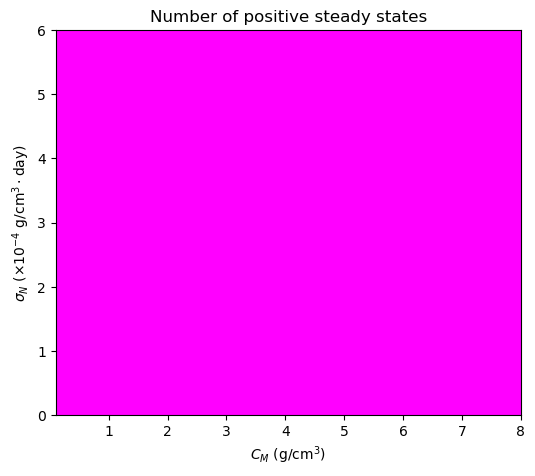